# Spam Detection — Full Overhaul

---




In [4]:
#https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

In [5]:
# Environment / packages
# If you run this in Colab or your environment, uncomment the pip installs if packages are missing.
# !pip install -q xgboost scikit-learn tensorflow datasets imbalanced-learn matplotlib seaborn nltk gensim
# For transformers (optional): !pip install -q transformers

import os, random, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
import nltk
nltk.download('punkt')
nltk.download('stopwords')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

print('Setup complete')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Setup complete


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [6]:
# Load dataset
data_path = '/content/spam.csv'
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found at {data_path}. Upload spam.csv to /mnt/data and re-run.")

df = pd.read_csv(data_path, encoding='latin-1')
# many spam.csv variants have extra unnamed cols: keep only common ones
if 'v1' in df.columns and 'v2' in df.columns:
    df = df[['v1','v2']].rename(columns={'v1':'label','v2':'text'})
elif 'label' in df.columns and 'text' in df.columns:
    df = df[['label','text']]
else:
    # try common names
    cols = df.columns.tolist()
    print('Columns found:', cols)
    # attempt to find first two useful columns
    df = df.iloc[:, :2].copy()
    df.columns = ['label','text']

df['label'] = df['label'].map(lambda x: x.strip().lower() if isinstance(x,str) else x)
df['label'] = df['label'].map(lambda x: 1 if x in ['spam','1','true','t'] else 0)
df = df.dropna().reset_index(drop=True)
print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (5572, 2)


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## Exploratory Data Analysis (EDA)

label
0    4825
1     747
Name: count, dtype: int64


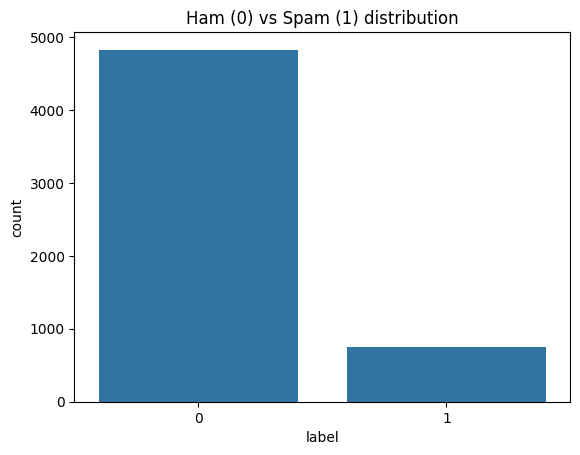

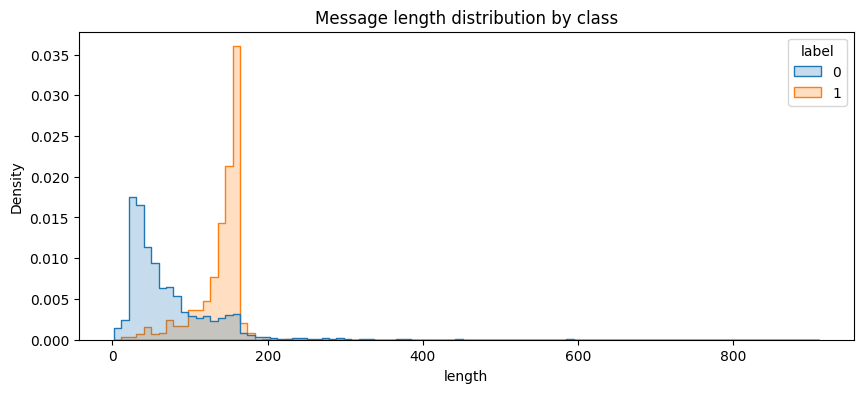

In [7]:
# Basic EDA
print(df['label'].value_counts())
sns.countplot(x='label', data=df)
plt.title('Ham (0) vs Spam (1) distribution')
plt.show()

# Message length distribution
df['length'] = df['text'].apply(lambda x: len(str(x)))
plt.figure(figsize=(10,4))
sns.histplot(data=df, x='length', hue='label', element='step', stat='density', common_norm=False)
plt.title('Message length distribution by class')
plt.show()

## Preprocessing: cleaning, tokenization, stopwords, stemming/lemmatization

In [8]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
nltk.download('wordnet')
nltk.download('punkt_tab') # Add this line to download the missing resource

stop_words = set(stopwords.words('english'))
ps = PorterStemmer()
wl = WordNetLemmatizer()

def clean_text_light(s):
    s = str(s).lower()
    s = re.sub(r'http\S+', ' URL ', s)   # keep URL signal
    s = re.sub(r'\d+', ' NUMBER ', s)    # normalize numbers
    s = re.sub(r'[^a-z!? ]', ' ', s)     # keep ! and ?
    s = re.sub(r'\s+', ' ', s).strip()
    return s

important_stopwords = {'not', 'no', 'never', 'now'}

custom_stopwords = stop_words - important_stopwords

def tokenize_and_process_fixed(s, remove_stopwords=False):
    s = clean_text_light(s)
    tokens = word_tokenize(s)

    if remove_stopwords:
        tokens = [t for t in tokens if t not in custom_stopwords]

    return ' '.join(tokens)

# apply
df['clean_text'] = df['text'].apply(tokenize_and_process_fixed)
display(df[['text','clean_text']].head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


## Feature extraction: TF-IDF (sparse)

In [9]:
# TF-IDF
tfidf = TfidfVectorizer(ngram_range=(1,2), max_df=0.95, min_df=2, max_features=20000)
X_tfidf = tfidf.fit_transform(df['clean_text'])
y = df['label'].values
print('TF-IDF shape:', X_tfidf.shape)

TF-IDF shape: (5572, 14083)


In [10]:
# Train-test split (stratified)
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)
print('Train/test sizes:', X_train_tfidf.shape, X_test_tfidf.shape)

Train/test sizes: (4457, 14083) (1115, 14083)


## Baselines: MultinomialNB and Logistic Regression

In [11]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

models = {}
mnb = MultinomialNB()
mnb.fit(X_train_tfidf, y_train)
y_pred = mnb.predict(X_test_tfidf)
print('MultinomialNB')
print(classification_report(y_test, y_pred))
models['MultinomialNB'] = (mnb, accuracy_score(y_test,y_pred))

lr = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr.fit(X_train_tfidf, y_train)
y_pred = lr.predict(X_test_tfidf)
print('LogisticRegression')
print(classification_report(y_test, y_pred))
models['LogisticRegression'] = (lr, accuracy_score(y_test,y_pred))

MultinomialNB
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.72      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115

LogisticRegression
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       966
           1       0.99      0.68      0.80       149

    accuracy                           0.96      1115
   macro avg       0.97      0.84      0.89      1115
weighted avg       0.96      0.96      0.95      1115



## Advanced ML: XGBoost (works well with sparse input)

In [12]:
# XGBoost - if xgboost is installed
try:
    from xgboost import XGBClassifier
    xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_SEED)
    xgb.fit(X_train_tfidf, y_train)
    y_pred = xgb.predict(X_test_tfidf)
    print('XGBoost')
    print(classification_report(y_test, y_pred))
    models['XGBoost'] = (xgb, accuracy_score(y_test,y_pred))
except Exception as e:
    print('XGBoost not available in this environment or failed to run:', e)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:21:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       0.97      0.83      0.90       149

    accuracy                           0.97      1115
   macro avg       0.97      0.91      0.94      1115
weighted avg       0.97      0.97      0.97      1115



## Stacking ensemble: combine Logistic + XGBoost + Naive Bayes with meta learner

In [13]:
from sklearn.ensemble import StackingClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier

estimators = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('mnb', MultinomialNB())
]

try:
    # if XGBoost exists, include it
    from xgboost import XGBClassifier
    estimators.append(('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss')))
except:
    pass

stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), n_jobs=-1)
stack.fit(X_train_tfidf, y_train)
y_pred = stack.predict(X_test_tfidf)
print('StackingClassifier')
print(classification_report(y_test, y_pred))
models['Stacking'] = (stack, accuracy_score(y_test,y_pred))

StackingClassifier
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.99      0.85      0.91       149

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



## Deep Learning models: Embedding + BiLSTM and CNN (Keras)


In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Conv1D, GlobalMaxPool1D, Dropout
from tensorflow.keras.optimizers import Adam

# Tokenizer on cleaned text
MAX_WORDS = 20000 #keep top 20k most frequent words in vocabulary
MAX_LEN = 100 #Each message will be padded/truncated to 100 tokens

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_text'])
sequences = tokenizer.texts_to_sequences(df['clean_text'])
X_seq = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y_seq = df['label'].values

# split
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(X_seq, y_seq, test_size=0.2, stratify=y_seq, random_state=RANDOM_SEED)

print('sequence shapes:', X_train_seq.shape, X_test_seq.shape)

sequence shapes: (4457, 100) (1115, 100)


In [15]:
# BiLSTM model
EMB_DIM = 100
bilstm = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMB_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
bilstm.compile(loss='binary_crossentropy', optimizer=Adam(1e-3), metrics=['accuracy'])
bilstm.summary()
history_bi = bilstm.fit(X_train_seq, y_train_seq, validation_split=0.1, epochs=5, batch_size=64, verbose=1)
# evaluate
loss, acc = bilstm.evaluate(X_test_seq, y_test_seq, verbose=0)
print('BiLSTM test acc:', acc)
y_pred = (bilstm.predict(X_test_seq) > 0.5).astype('int32')
print(classification_report(y_test_seq, y_pred))
#model added to dict
loss, acc = bilstm.evaluate(X_test_seq, y_test_seq, verbose=0)
models['BiLSTM'] = (bilstm, acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 333ms/step - accuracy: 0.8308 - loss: 0.4083 - val_accuracy: 0.9619 - val_loss: 0.1246
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 320ms/step - accuracy: 0.9827 - loss: 0.0685 - val_accuracy: 0.9865 - val_loss: 0.0546
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 191ms/step - accuracy: 0.9924 - loss: 0.0330 - val_accuracy: 0.9821 - val_loss: 0.0494
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step - accuracy: 0.9970 - loss: 0.0125 - val_accuracy: 0.9933 - val_loss: 0.0380
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 201ms/step - accuracy: 0.9991 - loss: 0.0069 - val_accuracy: 0.9888 - val_loss: 0.0452
BiLSTM test acc: 0.9856502413749695
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.97      0.93      0.95       149

    accuracy                           0.99      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg

In [16]:
# CNN model for text
cnn = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMB_DIM, input_length=MAX_LEN),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    GlobalMaxPool1D(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
cnn.compile(loss='binary_crossentropy', optimizer=Adam(1e-3), metrics=['accuracy'])
cnn.summary()
history_cnn = cnn.fit(X_train_seq, y_train_seq, validation_split=0.1, epochs=5, batch_size=64, verbose=1)
loss, acc = cnn.evaluate(X_test_seq, y_test_seq, verbose=0)
print('CNN test acc:', acc)
y_pred = (cnn.predict(X_test_seq) > 0.5).astype('int32')
print(classification_report(y_test_seq, y_pred))
#model added to dict
loss_cnn, acc_cnn = cnn.evaluate(X_test_seq, y_test_seq, verbose=0)
models['CNN'] = (cnn, acc_cnn)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.8505 - loss: 0.4775 - val_accuracy: 0.8453 - val_loss: 0.3143
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.9142 - loss: 0.2120 - val_accuracy: 0.9709 - val_loss: 0.1008
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.9830 - loss: 0.0539 - val_accuracy: 0.9776 - val_loss: 0.0733
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9941 - loss: 0.0233 - val_accuracy: 0.9776 - val_loss: 0.0648
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.9948 - loss: 0.0167 - val_accuracy: 0.9776 - val_loss: 0.0636
CNN test acc: 0.9820627570152283
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.94      0.93      0.93       149

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98  

### TRANSFORMER EMBEDDING + ML CLASSIFIER

In [17]:
from sklearn.model_selection import train_test_split

X_text = df['text']
y = df['label']   # spam = 1, ham = 0

X_train_text, X_test_text, y_train, y_test = train_test_split(X_text, y, test_size=0.2, stratify=y, random_state=42)

In [18]:
from sentence_transformers import SentenceTransformer
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score

# LLM Embedding
llm_model = SentenceTransformer("all-MiniLM-L6-v2")

# Encode after split
X_train_llm = llm_model.encode(X_train_text.tolist(), show_progress_bar=True)
X_test_llm  = llm_model.encode(X_test_text.tolist(), show_progress_bar=True)

# XGBoost on LLM embeddings
llm_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42
)

llm_xgb.fit(X_train_llm, y_train)

# Prediction
y_pred_llm_xgb = llm_xgb.predict(X_test_llm)

# Metrics
acc_llm_xgb = accuracy_score(y_test, y_pred_llm_xgb)
prec_llm_xgb = precision_score(y_test, y_pred_llm_xgb, pos_label=1)

print("LLM + XGBoost")
print("Accuracy:", acc_llm_xgb)
print("Precision:", prec_llm_xgb)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/140 [00:00<?, ?it/s]

Batches:   0%|          | 0/35 [00:00<?, ?it/s]

LLM + XGBoost
Accuracy: 0.9847533632286996
Precision: 0.9925373134328358


### HYBRID + LLM MODEL (TF-IDF + LLM EMBEDDINGS) AND TRAINING WITH LINEAR SVM ALGO

In [19]:
from sklearn.model_selection import train_test_split

X_text = df['text']
y = df['label']   # spam = 1, ham = 0

X_train_text, X_test_text, y_train, y_test = train_test_split(X_text, y, test_size=0.2, stratify=y, random_state=42)

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from scipy.sparse import hstack

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

# ---- LLM embeddings (already split) ----
X_train_hybrid = hstack([X_train_tfidf, X_train_llm])
X_test_hybrid  = hstack([X_test_tfidf, X_test_llm])

# ---- SVM ----
svm_model = LinearSVC(C=1.0, max_iter=5000)
svm_model.fit(X_train_hybrid, y_train)

y_pred_hybrid = svm_model.predict(X_test_hybrid)

acc_hybrid = accuracy_score(y_test, y_pred_hybrid)
prec_hybrid = precision_score(y_test, y_pred_hybrid, pos_label=1)

print("Hybrid TF-IDF + LLM + SVM")
print("Accuracy:", acc_hybrid)
print("Precision:", prec_hybrid)

Hybrid TF-IDF + LLM + SVM
Accuracy: 0.9946188340807175
Precision: 1.0


### END-TO-END LLM FINE-TUNING (BERT)

In [21]:
from sklearn.model_selection import train_test_split

X_text = df['text']
y = df['label']   # spam = 1, ham = 0

X_train_text, X_test_text, y_train, y_test = train_test_split(X_text, y, test_size=0.2, stratify=y, random_state=42)

In [22]:
'''
import torch
import numpy as np
from datasets import Dataset, Features, ClassLabel, Value # Import Value
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# No dataset cleaning for this model

df = pd.read_csv("/content/spam.csv", encoding='latin-1')

# Apply the same column renaming and initial preprocessing as in cell 39f4b75a
if 'v1' in df.columns and 'v2' in df.columns:
    df = df[['v1','v2']].rename(columns={'v1':'label','v2':'text'})
elif 'label' in df.columns and 'text' in df.columns:
    df = df[['label','text']]
else:
    cols = df.columns.tolist()
    print('Columns found:', cols)
    df = df.iloc[:, :2].copy()
    df.columns = ['label','text']

df['label'] = df['label'].map(lambda x: x.strip().lower() if isinstance(x,str) else x)
df['label'] = df['label'].map(lambda x: 1 if x in ['spam','1','true','t'] else 0)
df = df.dropna().reset_index(drop=True)

# Convert label column to ClassLabel feature
features = Features({'text': Value('string'), 'label': ClassLabel(num_classes=2, names=['ham', 'spam'])}) # Use Value('string')
dataset = Dataset.from_pandas(df, features=features)

dataset = dataset.train_test_split(test_size=0.2, stratify_by_column="label")

tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding=True,
        truncation=True,
        max_length=128
    )

dataset = dataset.map(tokenize, batched=True)
dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

training_args = TrainingArguments(
    output_dir="./bert_spam",
    eval_strategy="epoch", # Changed from evaluation_strategy
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

trainer.evaluate()
'''

'\nimport torch\nimport numpy as np\nfrom datasets import Dataset, Features, ClassLabel, Value # Import Value\nfrom transformers import (\n    BertTokenizerFast,\n    BertForSequenceClassification,\n    Trainer,\n    TrainingArguments\n)\nfrom sklearn.metrics import accuracy_score, precision_recall_fscore_support\n\n# No dataset cleaning for this model\n\ndf = pd.read_csv("/content/spam.csv", encoding=\'latin-1\')\n\n# Apply the same column renaming and initial preprocessing as in cell 39f4b75a\nif \'v1\' in df.columns and \'v2\' in df.columns:\n    df = df[[\'v1\',\'v2\']].rename(columns={\'v1\':\'label\',\'v2\':\'text\'})\nelif \'label\' in df.columns and \'text\' in df.columns:\n    df = df[[\'label\',\'text\']]\nelse:\n    cols = df.columns.tolist()\n    print(\'Columns found:\', cols)\n    df = df.iloc[:, :2].copy()\n    df.columns = [\'label\',\'text\']\n\ndf[\'label\'] = df[\'label\'].map(lambda x: x.strip().lower() if isinstance(x,str) else x)\ndf[\'label\'] = df[\'label\'].map

In [31]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
import numpy as np
import joblib
import os

results_data = {}

df['clean_text'] = df['text'].apply(tokenize_and_process_fixed)

original_tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2), max_df=0.95, min_df=2, max_features=20000)
original_tfidf_vectorizer.fit(df['clean_text']) # Fit on the entire cleaned text dataset

# Prepare X_test_text for TF-IDF models
cleaned_X_test_text = X_test_text.apply(tokenize_and_process_fixed)


X_test_tfidf_original_features = original_tfidf_vectorizer.transform(cleaned_X_test_text)

# --- Classical ML Models (TF-IDF based) ---

# Multinomial Naive Bayes
y_pred_mnb = mnb.predict(X_test_tfidf_original_features)
results_data["MultinomialNB"] = {
    "accuracy": models['MultinomialNB'][1],
    "precision": precision_score(y_test, y_pred_mnb, pos_label=1)
}

# Logistic Regression
y_pred_lr = lr.predict(X_test_tfidf_original_features)
results_data["LogisticRegression"] = {
    "accuracy": models['LogisticRegression'][1],
    "precision": precision_score(y_test, y_pred_lr, pos_label=1)
}

# XGBoost
try:
    from xgboost import XGBClassifier
    y_pred_xgb = xgb.predict(X_test_tfidf_original_features)
    results_data["XGBoost"] = {
        "accuracy": models['XGBoost'][1],
        "precision": precision_score(y_test, y_pred_xgb, pos_label=1)
    }
except NameError:
    print('XGBoost model not found or not trained, skipping.')
except Exception as e:
    print(f'Error predicting with XGBoost: {e}, skipping.')

# Stacking Ensemble
y_pred_stack = stack.predict(X_test_tfidf_original_features)
results_data["Stacking"] = {
    "accuracy": models['Stacking'][1],
    "precision": precision_score(y_test, y_pred_stack, pos_label=1)
}

# --- Deep Learning Models (Sequential data) ---

# BiLSTM
y_pred_bilstm = (bilstm.predict(X_test_seq, verbose=0) > 0.5).astype('int32')
results_data["BiLSTM"] = {
    "accuracy": models['BiLSTM'][1],
    "precision": precision_score(y_test_seq, y_pred_bilstm, pos_label=1)
}

# CNN
y_pred_cnn = (cnn.predict(X_test_seq, verbose=0) > 0.5).astype('int32')
results_data["CNN"] = {
    "accuracy": models['CNN'][1],
    "precision": precision_score(y_test_seq, y_pred_cnn, pos_label=1)
}

# --- LLM-based Models (metrics already computed and available) ---

# LLM + XGBoost
if 'acc_llm_xgb' in globals() and 'prec_llm_xgb' in globals():
    results_data["LLM + XGBoost"] = {
        "accuracy": acc_llm_xgb,
        "precision": prec_llm_xgb
    }
else:
    print("LLM + Logistic Regression metrics not found, skipping.")

# Hybrid (TF-IDF + LLM) + SVM
if 'acc_hybrid' in globals() and 'prec_hybrid' in globals():
    results_data["Hybrid (TF-IDF + LLM) + SVM"] = {
        "accuracy": acc_hybrid,
        "precision": prec_hybrid
    }
else:
    print("Hybrid (TF-IDF + LLM) + SVM metrics not found, skipping.")

# Create DataFrame
results_df = pd.DataFrame(results_data).T

print("Model Comparison Results:")
display(results_df)

Model Comparison Results:


,accuracy,precision
MultinomialNB,0.962332,1.000000
LogisticRegression,0.956054,0.990196
XGBoost,0.973991,0.968750
Stacking,0.978475,0.992126
BiLSTM,0.985650,0.965035
CNN,0.982063,0.938776
LLM + XGBoost,0.984753,0.992537
Hybrid (TF-IDF + LLM) + SVM,0.994619,1.000000


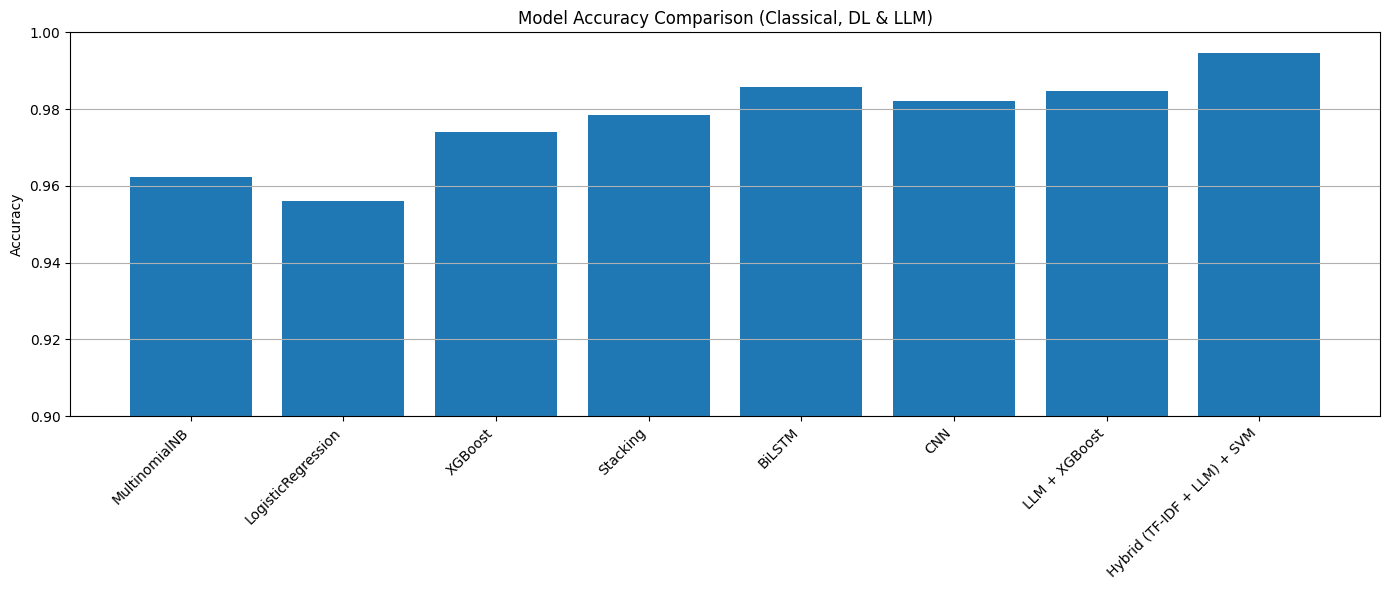

In [32]:
#accuracy plot

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.bar(results_df.index, results_df["accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.0)
plt.title("Model Accuracy Comparison (Classical, DL & LLM)")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

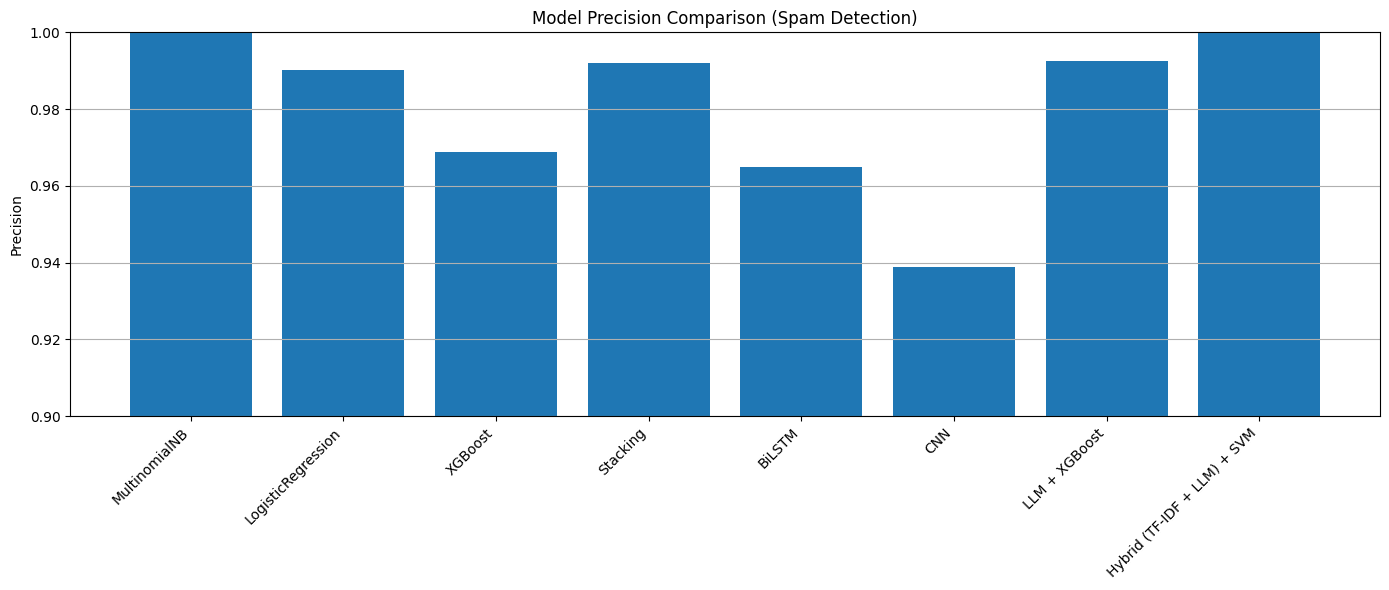

In [33]:
#precision plot

plt.figure(figsize=(14,6))
plt.bar(results_df.index, results_df["precision"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Precision")
plt.ylim(0.9, 1.0)
plt.title("Model Precision Comparison (Spam Detection)")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [34]:
import pandas as pd

# results_df = pd.DataFrame(model_metrics).T

results_df.to_csv("sms_spam_model_comparison_results.csv")

## Evaluation utilities: confusion matrix, ROC curve, summary table

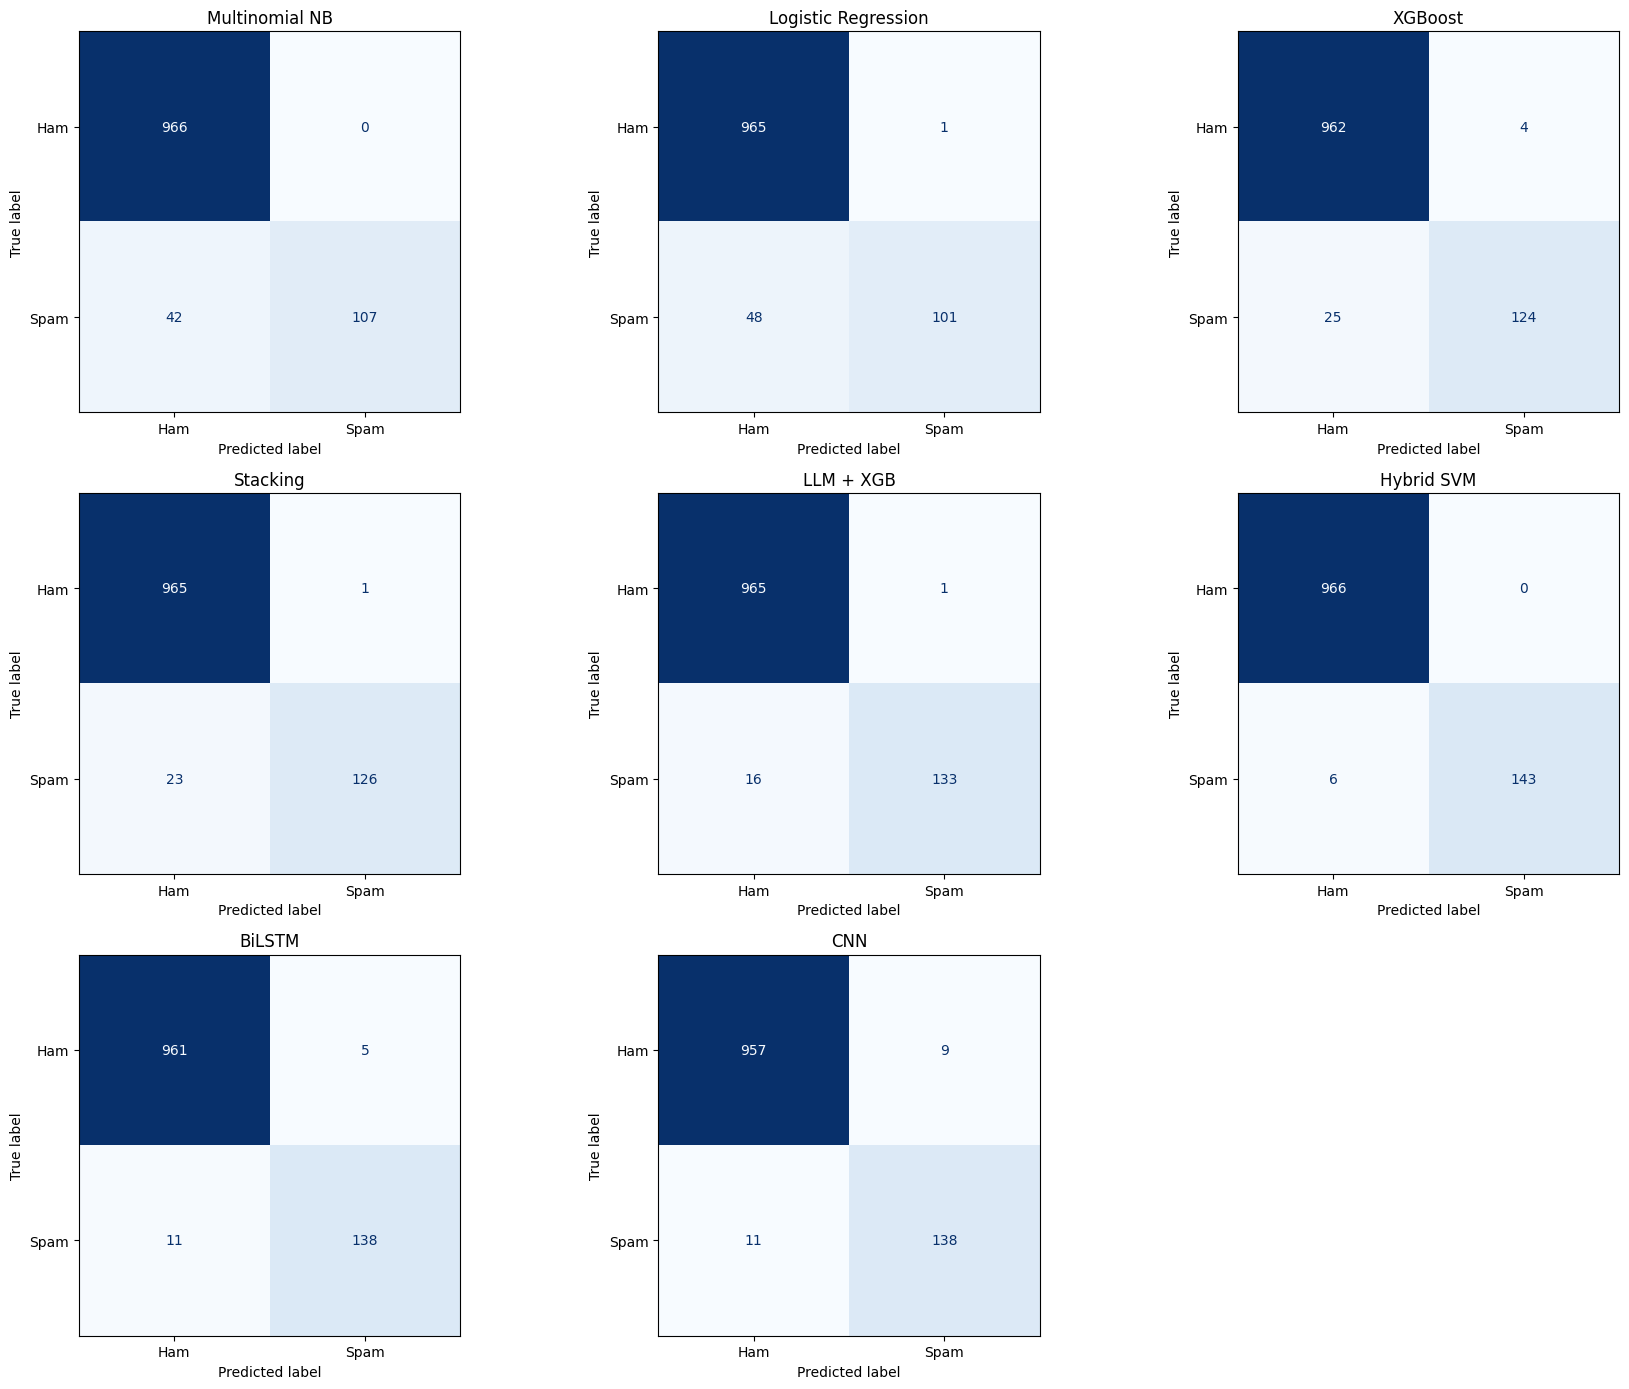

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models_preds = {
    "Multinomial NB": (y_test, y_pred_mnb),
    "Logistic Regression": (y_test, y_pred_lr),
    "XGBoost": (y_test, y_pred_xgb),
    "Stacking": (y_test, y_pred_stack),
    "LLM + XGB": (y_test, y_pred_llm_xgb),
    "Hybrid SVM": (y_test, y_pred_hybrid),
    "BiLSTM": (y_test_seq, y_pred_bilstm),
    "CNN": (y_test_seq, y_pred_cnn)
}

plt.figure(figsize=(18, 14))

i = 1
for model_name, (y_true, y_pred) in models_preds.items():
    plt.subplot(3, 3, i)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham", "Spam"])
    disp.plot(cmap="Blues", values_format="d", ax=plt.gca(), colorbar=False)
    plt.title(model_name)
    i += 1

plt.tight_layout()
plt.show()

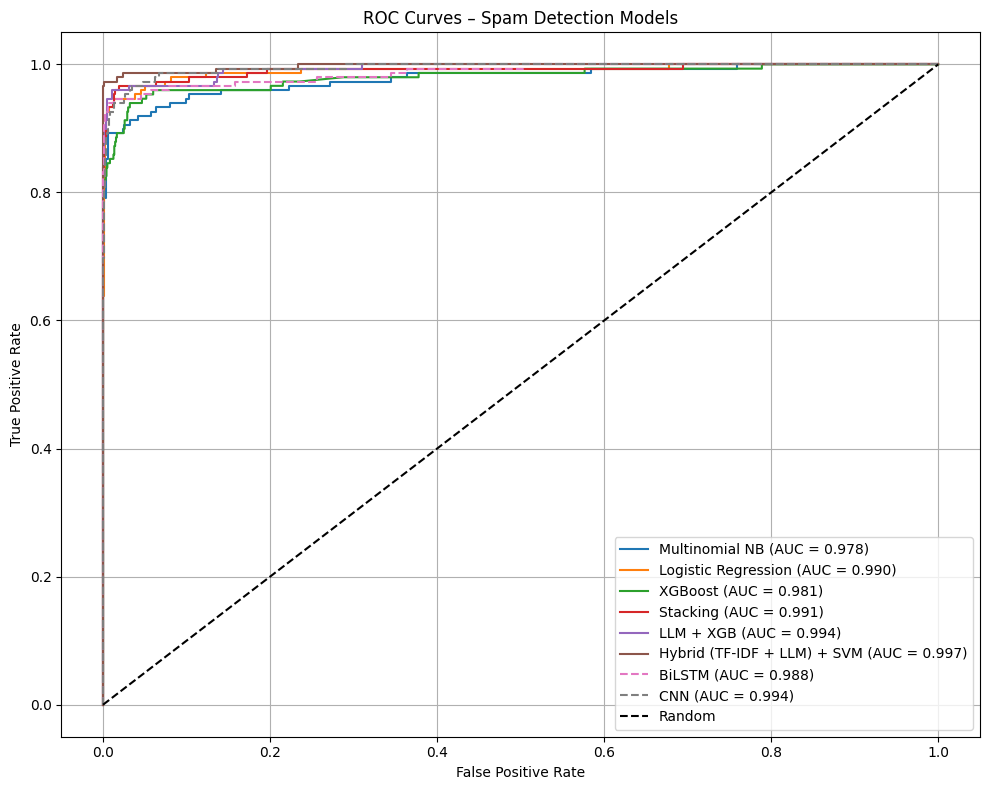

In [36]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# ==============================
# Classical + LLM-based models
# ==============================

models_scores = {
    "Multinomial NB": mnb.predict_proba(X_test_tfidf_original_features)[:, 1],
    "Logistic Regression": lr.predict_proba(X_test_tfidf_original_features)[:, 1],
    "XGBoost": xgb.predict_proba(X_test_tfidf_original_features)[:, 1],
    "Stacking": stack.predict_proba(X_test_tfidf_original_features)[:, 1],
    "LLM + XGB": llm_xgb.predict_proba(X_test_llm)[:, 1],
    "Hybrid (TF-IDF + LLM) + SVM": svm_model.decision_function(X_test_hybrid)
}

for name, scores in models_scores.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# ==============================
# Deep Learning models
# ==============================

bilstm_probs = bilstm.predict(X_test_seq, verbose=0).ravel()
cnn_probs = cnn.predict(X_test_seq, verbose=0).ravel()

for name, probs in {
    "BiLSTM": bilstm_probs,
    "CNN": cnn_probs
}.items():
    fpr, tpr, _ = roc_curve(y_test_seq, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linestyle="--", label=f"{name} (AUC = {roc_auc:.3f})")

# ==============================
# Random baseline
# ==============================

plt.plot([0, 1], [0, 1], "k--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – Spam Detection Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

## Reproducibility & Experiment Logging

In [37]:
import joblib
artifacts_dir = '/mnt/data/artifacts'
os.makedirs(artifacts_dir, exist_ok=True)
joblib.dump(tfidf, os.path.join(artifacts_dir, 'tfidf_vectorizer.joblib'))
joblib.dump(tokenizer, os.path.join(artifacts_dir, 'tokenizer.joblib'))
# Save sklearn models
joblib.dump(lr, os.path.join(artifacts_dir, 'logistic_model.joblib'))
# Save keras models
bilstm.save(os.path.join(artifacts_dir, 'bilstm_model.h5'))
cnn.save(os.path.join(artifacts_dir, 'cnn_model.h5'))
print('Artifacts saved to', artifacts_dir)

Artifacts saved to /mnt/data/artifacts
